# Business Problem

**Predict whether a bank customer will subscribe to a term deposit based on customer information and previous marketing campaign details.**

**Business Goal**

Identify customers likely to subscribe.
Reduce marketing costs.
Improve campaign success rate.

**Target Variable**

deposit
yes → 1
no → 0

# Import Necessary Libraries

In [2]:
# Data Manipulation
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Model
from sklearn.linear_model import LogisticRegression

# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# Cross Validation & Hyperparameter Tuning
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

# Save Model
import joblib

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Load Dataset

In [3]:
bank_data = pd.read_csv("bank.csv")
bank_data

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


# Data Understanding

In [4]:
bank_data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [5]:
bank_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [6]:
bank_data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [8]:
bank_data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [10]:
bank_data.shape

(11162, 17)

In [12]:
bank_data["deposit"].value_counts()

deposit
no     5873
yes    5289
Name: count, dtype: int64

# Exploratory Data Analysis (EDA)

## 4.1 Univariate Analysis

### Age Distribution

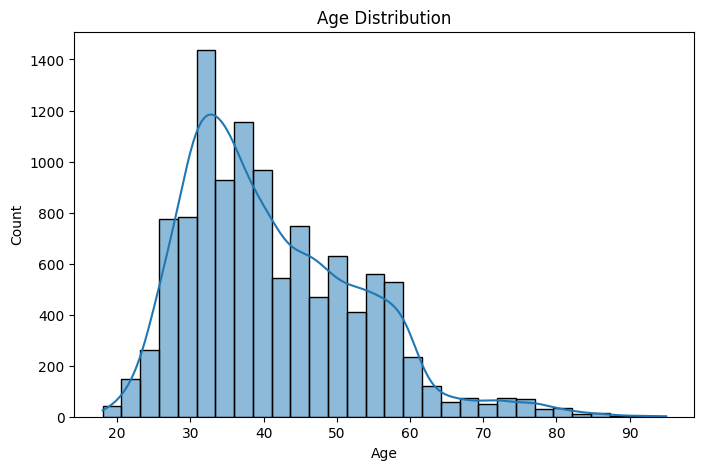

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(bank_data["age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

### Balance Distribution

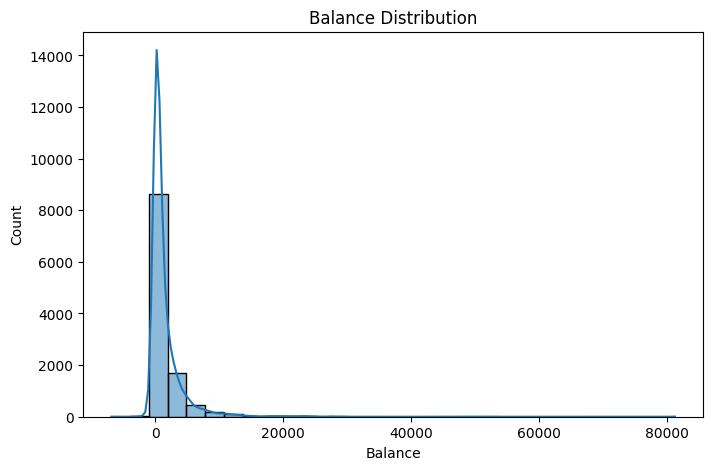

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(bank_data["balance"], bins=30, kde=True)
plt.title("Balance Distribution")
plt.xlabel("Balance")
plt.ylabel("Count")
plt.show()

### Job Count

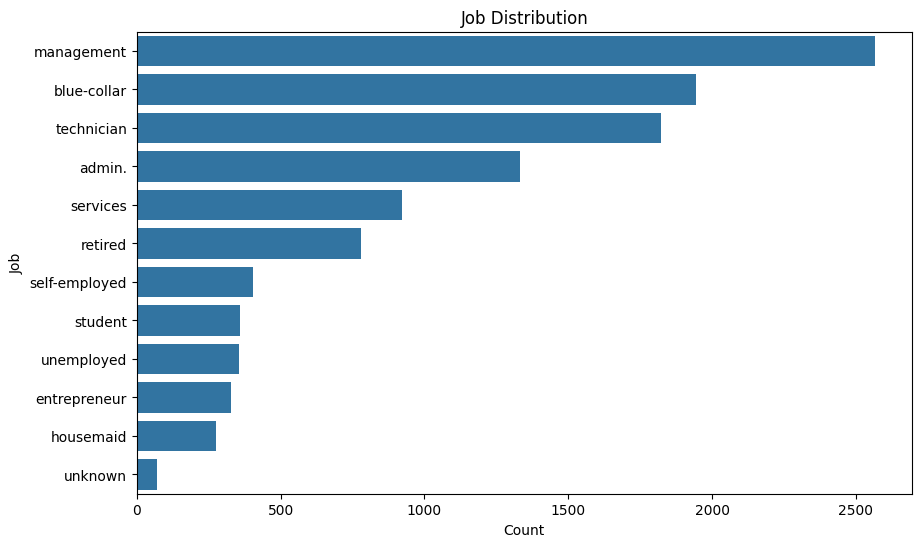

In [16]:
plt.figure(figsize=(10,6))
sns.countplot(data=bank_data, y="job", order=bank_data["job"].value_counts().index)
plt.title("Job Distribution")
plt.xlabel("Count")
plt.ylabel("Job")
plt.show()

### Education Count

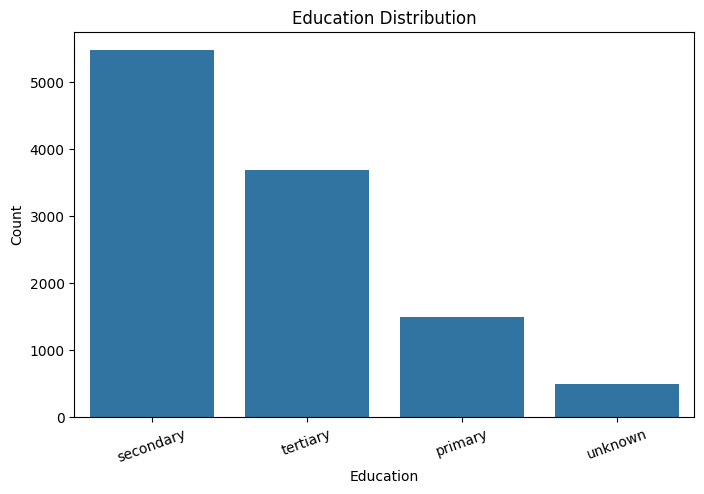

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(data=bank_data, x="education", order=bank_data["education"].value_counts().index)
plt.title("Education Distribution")
plt.xlabel("Education")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

### Deposit Count

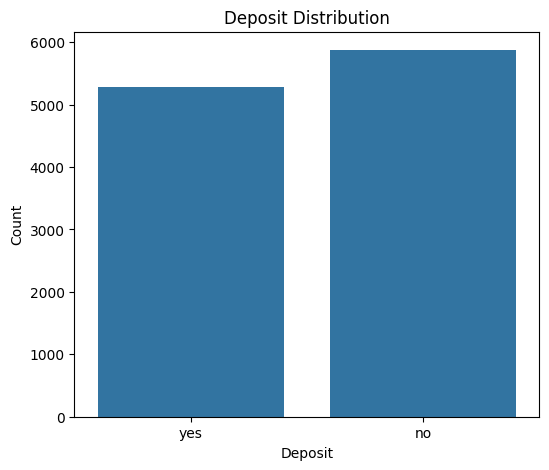

In [18]:
plt.figure(figsize=(6,5))
sns.countplot(data=bank_data, x="deposit")
plt.title("Deposit Distribution")
plt.xlabel("Deposit")
plt.ylabel("Count")
plt.show()

## 4.2 Bivariate Analysis

### Age vs Deposit

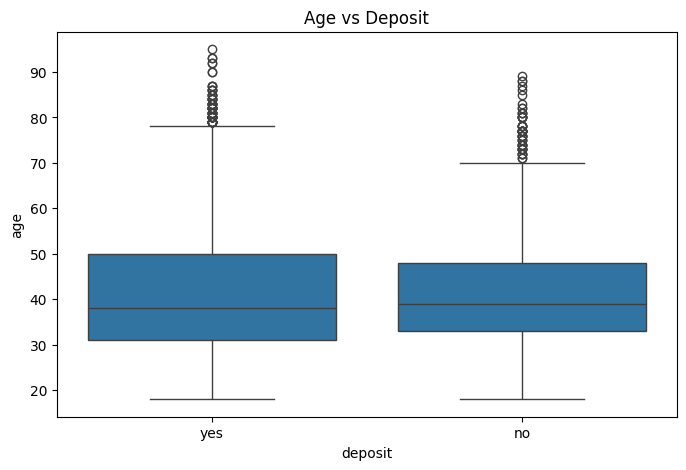

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(data=bank_data, x="deposit", y="age")
plt.title("Age vs Deposit")
plt.show()

### Balance vs Deposit

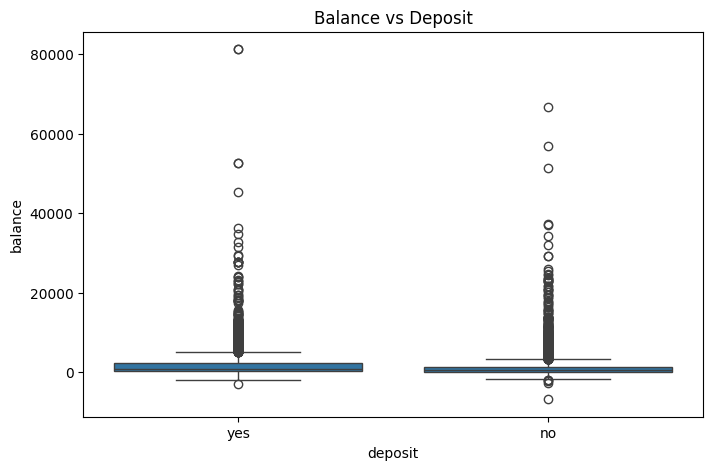

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(data=bank_data, x="deposit", y="balance")
plt.title("Balance vs Deposit")
plt.show()

### Job vs Deposit

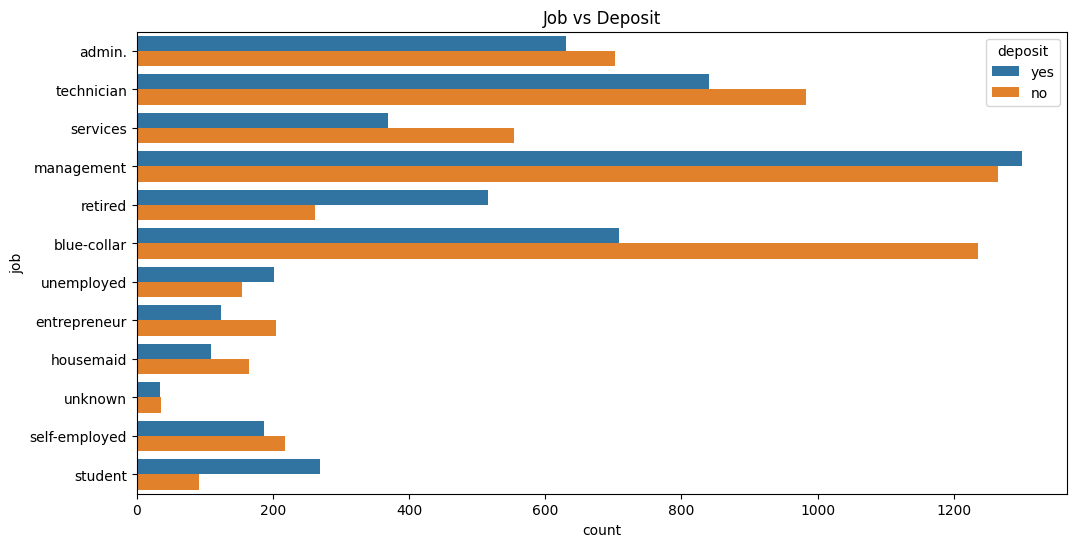

In [24]:
plt.figure(figsize=(12,6))
sns.countplot(data=bank_data, y="job", hue="deposit")
plt.title("Job vs Deposit")
plt.show()

### Education vs Deposit

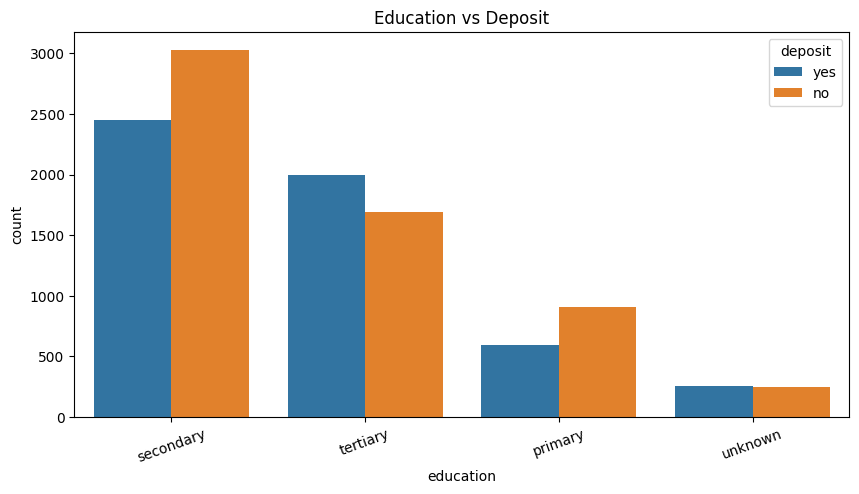

In [25]:
plt.figure(figsize=(10,5))
sns.countplot(data=bank_data, x="education", hue="deposit")
plt.title("Education vs Deposit")
plt.xticks(rotation=20)
plt.show()

### Housing Loan vs Deposit

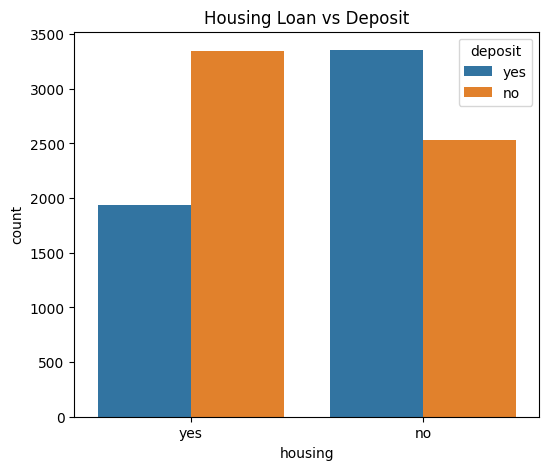

In [26]:
plt.figure(figsize=(6,5))
sns.countplot(data=bank_data, x="housing", hue="deposit")
plt.title("Housing Loan vs Deposit")
plt.show()

### Personal Loan vs Deposit

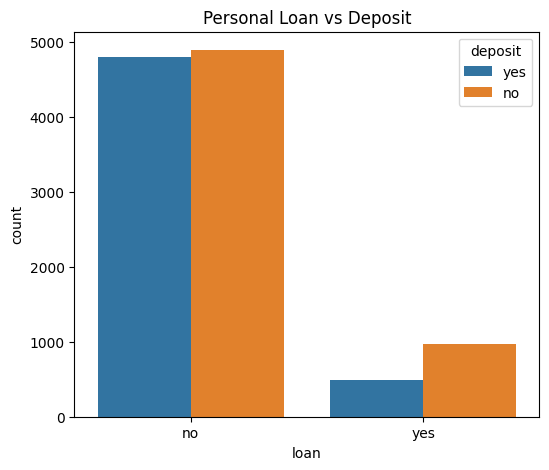

In [27]:
plt.figure(figsize=(6,5))
sns.countplot(data=bank_data, x="loan", hue="deposit")
plt.title("Personal Loan vs Deposit")
plt.show()

### Marital Status vs Deposit

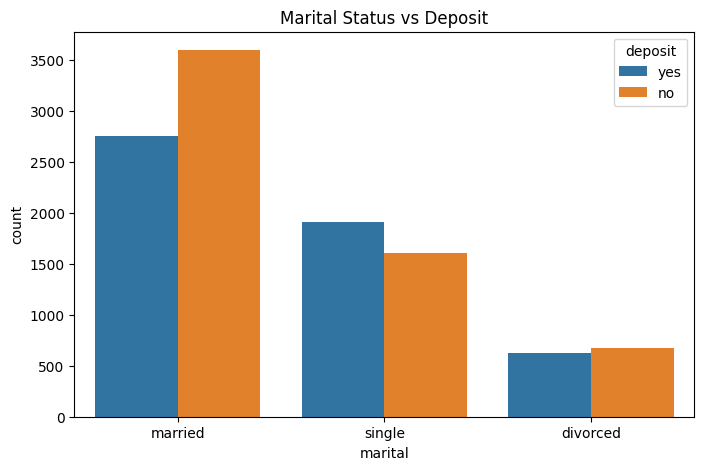

In [29]:
plt.figure(figsize=(8,5))
sns.countplot(data=bank_data, x="marital", hue="deposit")
plt.title("Marital Status vs Deposit")
plt.show()

### Default vs Deposit

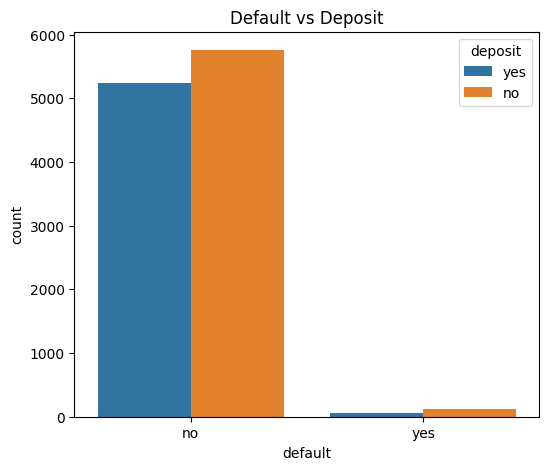

In [30]:
plt.figure(figsize=(6,5))
sns.countplot(data=bank_data, x="default", hue="deposit")
plt.title("Default vs Deposit")
plt.show()

## 4.3 Multivariate Analysis

### Age vs Balance vs Deposit

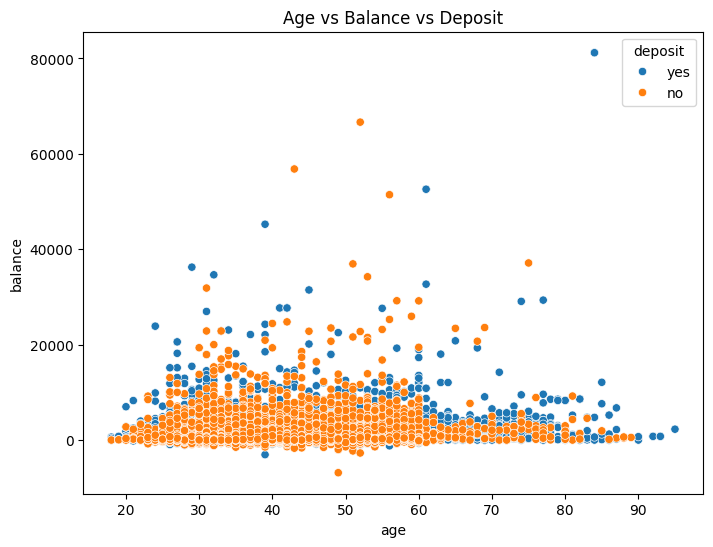

In [31]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=bank_data,
    x="age",
    y="balance",
    hue="deposit"
)
plt.title("Age vs Balance vs Deposit")
plt.show()

## Job + Education + Deposit

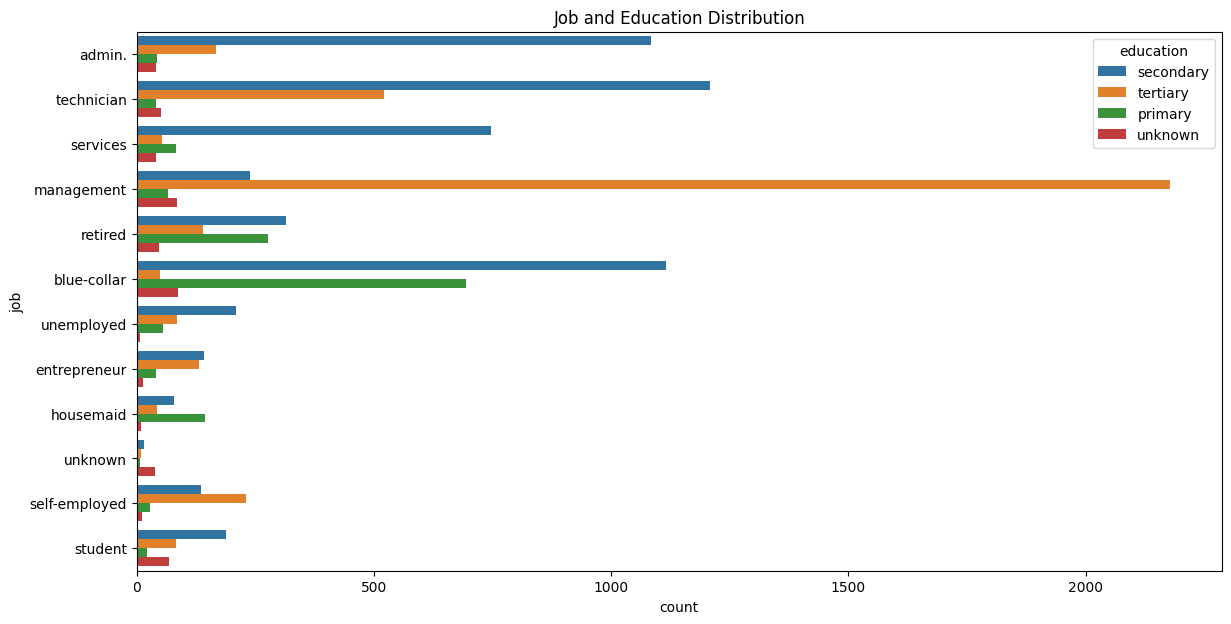

In [32]:
plt.figure(figsize=(14,7))
sns.countplot(
    data=bank_data,
    y="job",
    hue="education"
)
plt.title("Job and Education Distribution")
plt.show()

### Job vs Deposit (Faceted by Marital Status)

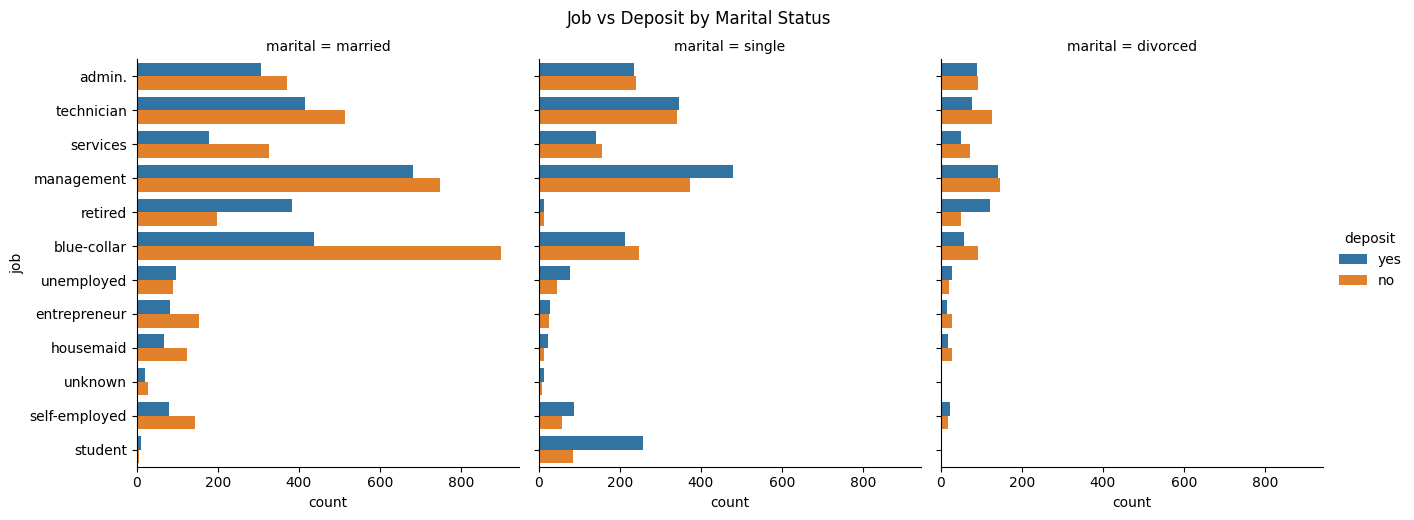

In [33]:
g = sns.catplot(
    data=bank_data,
    y="job",
    hue="deposit",
    col="marital",
    kind="count",
    height=5,
    aspect=0.9
)

g.fig.suptitle("Job vs Deposit by Marital Status", y=1.03)
plt.show()

### Correlation Heatmap (Numerical Features)

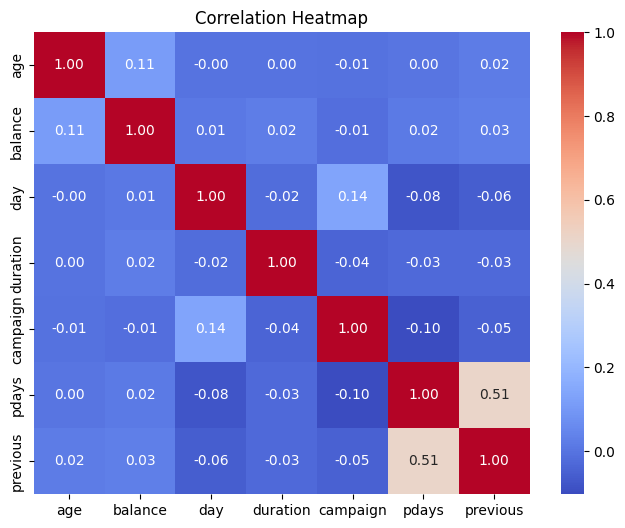

In [34]:
plt.figure(figsize=(8,6))

numeric_df = bank_data.select_dtypes(include=["int64", "float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### Pair Plot

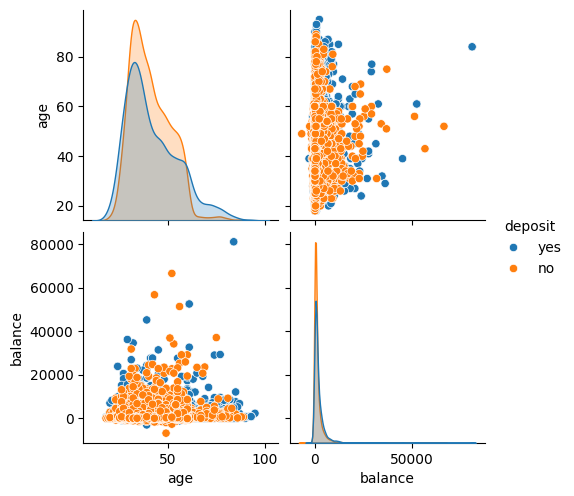

In [36]:
sns.pairplot(
    bank_data,
    vars=["age", "balance"],
    hue="deposit"
)

plt.show()

# Data Cleaning

In [37]:
bank_data.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [38]:
bank_data.duplicated().sum()

np.int64(0)

# Feature Selection

**Drop unnecessary columns**

For a realistic prediction model (predict before making a marketing call), drop columns that leak information or are not useful.

In [39]:
bank_data.drop(
    columns=[
        "contact",
        "day",
        "month",
        "duration",
        "campaign",
        "pdays",
        "previous",
        "poutcome"
    ],
    inplace=True
)

# Feature Engineering